In [8]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [9]:
# 1. Load Fashion MNIST data
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()


In [10]:
# 2. Preprocess (reshape for CNN and scale to [0,1])
X_train = X_train.reshape(-1,28,28,1) / 255.0  # Single channel BW
X_test = X_test.reshape(-1,28,28,1) / 255.0


In [11]:
# 3. Build the simple CNN model
model = Sequential([
    Conv2D(32, (3,3), strides=1, activation='relu', input_shape=(28,28,1)),  # convolutional layer with 32 filters, 3x3 kernel
    MaxPooling2D(pool_size=2),  # max pooling with 2x2 window
    Conv2D(64, (3,3), activation='relu'),     # deeper convolutional layer
    MaxPooling2D(pool_size=2),
    Flatten(),                                 # flatten for fully connected layers
    Dense(128, activation='relu'),             # hidden layer
    Dense(10, activation='softmax')            # output for 10 classes
])

In [12]:
# 4. Compile the CNN
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [13]:
# 5. Train the CNN (uses GPU automatically in Colab if available)
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), verbose=2)


Epoch 1/10
1875/1875 - 52s - 28ms/step - accuracy: 0.8354 - loss: 0.4528 - val_accuracy: 0.8766 - val_loss: 0.3499
Epoch 2/10
1875/1875 - 82s - 44ms/step - accuracy: 0.8911 - loss: 0.2971 - val_accuracy: 0.8936 - val_loss: 0.2997
Epoch 3/10
1875/1875 - 81s - 43ms/step - accuracy: 0.9063 - loss: 0.2536 - val_accuracy: 0.8987 - val_loss: 0.2765
Epoch 4/10
1875/1875 - 49s - 26ms/step - accuracy: 0.9187 - loss: 0.2203 - val_accuracy: 0.9001 - val_loss: 0.2652
Epoch 5/10
1875/1875 - 83s - 44ms/step - accuracy: 0.9271 - loss: 0.1956 - val_accuracy: 0.9063 - val_loss: 0.2597
Epoch 6/10
1875/1875 - 50s - 27ms/step - accuracy: 0.9356 - loss: 0.1726 - val_accuracy: 0.9137 - val_loss: 0.2455
Epoch 7/10
1875/1875 - 83s - 44ms/step - accuracy: 0.9434 - loss: 0.1517 - val_accuracy: 0.9095 - val_loss: 0.2616
Epoch 8/10
1875/1875 - 80s - 43ms/step - accuracy: 0.9483 - loss: 0.1350 - val_accuracy: 0.9098 - val_loss: 0.2622
Epoch 9/10
1875/1875 - 50s - 27ms/step - accuracy: 0.9548 - loss: 0.1200 - val_a

In [14]:
# 6. Evaluate
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9113 - loss: 0.2928
Test Accuracy: 91.28%


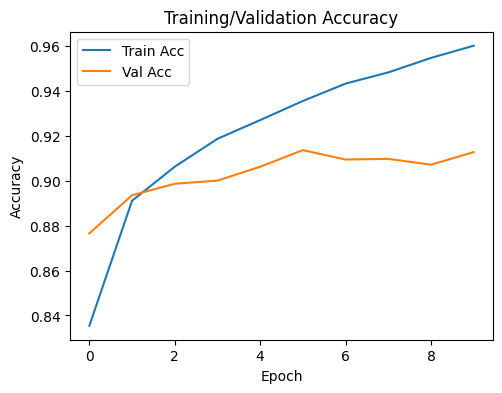

In [15]:
# 7. Visualize training progress (accuracy/loss)
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training/Validation Accuracy')
plt.legend()

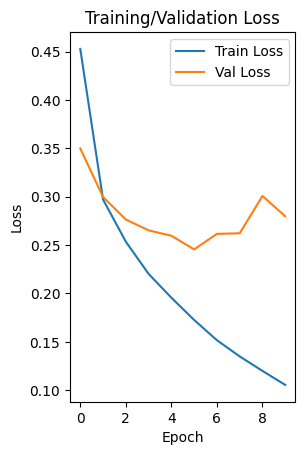

In [16]:
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training/Validation Loss')
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step


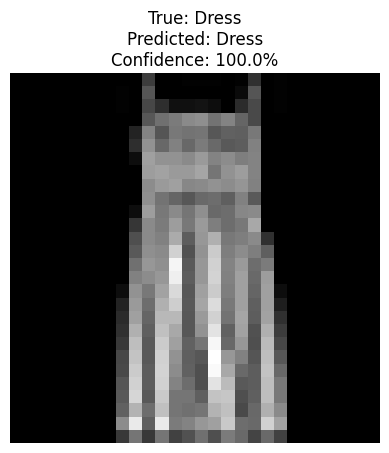

In [17]:
# 8. Predict a sample and visualize output & confidence
import numpy as np
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
sample_idx = np.random.randint(0, len(X_test))
img = X_test[sample_idx].reshape(28,28)
pred = model.predict(X_test[sample_idx].reshape(1,28,28,1))
plt.imshow(img, cmap='gray')
plt.title(f"True: {class_names[y_test[sample_idx]]}\nPredicted: {class_names[np.argmax(pred)]}\nConfidence: {np.max(pred)*100:.1f}%")
plt.axis('off')
plt.show()